In [ ]:
from PIL import Image
import os


dataset_path = "pretrained"

removed = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            print("Removing corrupted file:", path)
            os.remove(path)
            removed.append(path)

print("Total removed:", len(removed))

valid_extensions = (".jpg", ".jpeg", ".png")

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if not file.lower().endswith(valid_extensions):
            os.remove(os.path.join(root, file))

Total removed: 0


In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import image_dataset_from_directory, load_img, img_to_array
from tensorflow.data.experimental import ignore_errors
from tensorflow.data import AUTOTUNE
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, Dense, Flatten, Input
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

In [82]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_data = image_dataset_from_directory(
    "pretrained", labels="inferred",
    label_mode="binary", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, seed=123
)

Found 26010 files belonging to 2 classes.


In [83]:
train_data = train_data.map(lambda x, y: (x / 255.0, y))
train_data = train_data.apply(ignore_errors())
train_data = train_data.prefetch(AUTOTUNE)

In [165]:
# Model
model = Sequential([
  Input(shape = (150, 150, 3)),
  Conv2D(32, (3, 3), activation = 'relu'),
  MaxPooling2D((2,2)),
  Conv2D(32, (3,3), activation = 'relu'),
  MaxPooling2D((2,2)),
  Flatten(),
  Dense(64, activation = 'relu'),
  Dense(1, activation = 'sigmoid')
])

In [166]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [167]:
model.fit(train_data, epochs=5)

Epoch 1/5
806/806 ━━━━━━━━━━━━━━━━━━━━ 74s 90ms/step - accuracy: 0.6616 - loss: 0.6226
Epoch 2/5
  1/806 ━━━━━━━━━━━━━━━━━━━━ 2:32 189ms/step - accuracy: 0.7500 - loss: 0.5216

c:\Users\bk183\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


806/806 ━━━━━━━━━━━━━━━━━━━━ 73s 91ms/step - accuracy: 0.7702 - loss: 0.4752
Epoch 3/5
806/806 ━━━━━━━━━━━━━━━━━━━━ 71s 88ms/step - accuracy: 0.8496 - loss: 0.3374
Epoch 4/5
806/806 ━━━━━━━━━━━━━━━━━━━━ 70s 87ms/step - accuracy: 0.9181 - loss: 0.2015
Epoch 5/5
806/806 ━━━━━━━━━━━━━━━━━━━━ 71s 88ms/step - accuracy: 0.9600 - loss: 0.1065


In [168]:
model.save("dog_cat_model_image.keras")

In [169]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │     2,654,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,993,445 (30.49 MB)

 Trainable params: 2,664,481 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,328,964 (20.33 MB)

Image URL: https://cdn2.thecatapi.com/images/co3.jpg


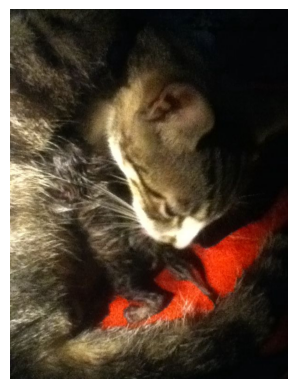

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction: Dog 🐶
Confidence: 0.5709072


In [176]:
IMG_SIZE = (150, 150)

api_url = "https://api.thecatapi.com/v1/images/search"
response = requests.get(api_url)

image_url = response.json()[0]["url"]
print("Image URL:", image_url)

response = requests.get(image_url)
img = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

img = img.resize(IMG_SIZE)
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

label = "Cat 🐱" if prediction < 0.5 else "Dog 🐶"

print("Prediction:", label)
print("Confidence:", prediction)